# Assignment 1: Riemann-Stieltjes Sums and the Itô Correction

**Objective:**
This notebook demonstrates a fundamental concept in continuous-time stochastic calculus: standard Riemann-Stieltjes integration rules break down when applied to Brownian motion. Because a standard Brownian path $W_t$ possesses **infinite total variation** but non-zero **quadratic variation**, the value of the stochastic integral $\int_0^1 W_s dW_s$ strictly depends on where we evaluate the integrand within each time step (left-endpoint, right-endpoint, or midpoint).

**Methodology & Theoretical Setup:**
We partition the time interval $[0, 1]$ into $n$ subintervals of length $\Delta t = 1/n$. We define the evaluation points $\xi_k \in [t_{k-1}, t_k]$ and compute the sum:
$$S_n = \sum_{k=1}^n W_{\xi_k} \Delta W_k$$
where $\Delta W_k = W_{t_k} - W_{t_{k-1}}$. 

We evaluate three distinct conventions and compare them to their analytical limits based on the algebraic identity $W_{t_{k-1}} \Delta W_k = \frac{1}{2}(\Delta W_k^2) - \frac{1}{2}(\Delta W_k)^2$:
1. **Left-Endpoint (Itô Convention, $\xi_k = t_{k-1}$):** Converges to $\frac{1}{2}(W_1^2 - 1)$. The $-1$ represents the Itô correction arising from the quadratic variation of Brownian motion.
2. **Right-Endpoint ($\xi_k = t_k$):** Converges to $\frac{1}{2}(W_1^2 + 1)$.
3. **Midpoint (Stratonovich Convention, $\xi_k = \frac{W_{t_{k-1}} + W_{t_k}}{2}$):** Converges exactly to $\frac{1}{2}W_1^2$, preserving standard calculus rules but losing the martingale property.

Finally, we use Monte Carlo simulation across 1,000 independent paths to prove that the expectations of these sums converge to $0$, $1$, and $0.5$, respectively.

---
### Initialization: Generating a Single Brownian Path

Before evaluating the individual sums, we first initialize our global parameters and generate a single Brownian trajectory over $[0, 1]$ with $n = 1000$ steps. This single path will be used across parts (a), (b), and (c) for a controlled, pathwise comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Global Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (10, 6)
})

# Parameters for single path
t = 1.0
n = 1000
dt = t / n

# Generate a single Brownian path
np.random.seed(42) # For reproducibility
dW = np.random.normal(0, np.sqrt(dt), n)
W = np.concatenate(([0.0], np.cumsum(dW)))
time_grid = np.linspace(0, t, n + 1)
W_1 = W[-1]

print(f"Base Brownian Path Generated. Terminal Value (W_1): {W_1:.4f}")

Base Brownian Path Generated. Terminal Value (W_1): 0.6113


---
### Part (a): Left-Endpoint Sum (Itô Convention)

We evaluate the Riemann sum using the left endpoint $\xi_k = t_{k-1}$. 
Analytically, this converges to $\frac{1}{2}(W_1^2 - t)$. The $-t$ term (which is $-1$ at $t=1$) represents the **Itô correction** arising from the nonzero quadratic variation of Brownian motion.

In [2]:
# (a) Compute left-endpoint sum
sum_left = np.sum(W[:-1] * dW)
analytical_left = 0.5 * (W_1**2 - 1.0)

print(f"--- (a) Left-Endpoint (Itô) ---")
print(f"Numerical Sum : {sum_left:.4f}")
print(f"Analytical    : {analytical_left:.4f}")
print(f"Difference    : {abs(sum_left - analytical_left):.4f}")

--- (a) Left-Endpoint (Itô) ---
Numerical Sum : -0.2923
Analytical    : -0.3131
Difference    : 0.0209


---
### Part (b): Right-Endpoint Sum

We evaluate the Riemann sum using the right endpoint $\xi_k = t_k$. 
Because the evaluation point is moved forward, the quadratic variation is added rather than subtracted. Analytically, this converges to $\frac{1}{2}(W_1^2 + 1)$.

In [3]:
# (b) Compute right-endpoint sum
sum_right = np.sum(W[1:] * dW)
analytical_right = 0.5 * (W_1**2 + 1.0)

print(f"--- (b) Right-Endpoint ---")
print(f"Numerical Sum : {sum_right:.4f}")
print(f"Analytical    : {analytical_right:.4f}")
print(f"Difference    : {abs(sum_right - analytical_right):.4f}")

--- (b) Right-Endpoint ---
Numerical Sum : 0.6660
Analytical    : 0.6869
Difference    : 0.0209


---
### Part (c): Midpoint Sum (Stratonovich Convention)

We evaluate the Riemann sum using the state average $\xi_k = \frac{W_{t_{k-1}} + W_{t_k}}{2}$.
This algebraically telescopes to exactly $\frac{1}{2}W_1^2$, preserving standard calculus rules but losing the martingale property.

--- (c) Midpoint (Stratonovich) ---
Numerical Sum : 0.1869
Analytical    : 0.1869
Difference    : 0.0000



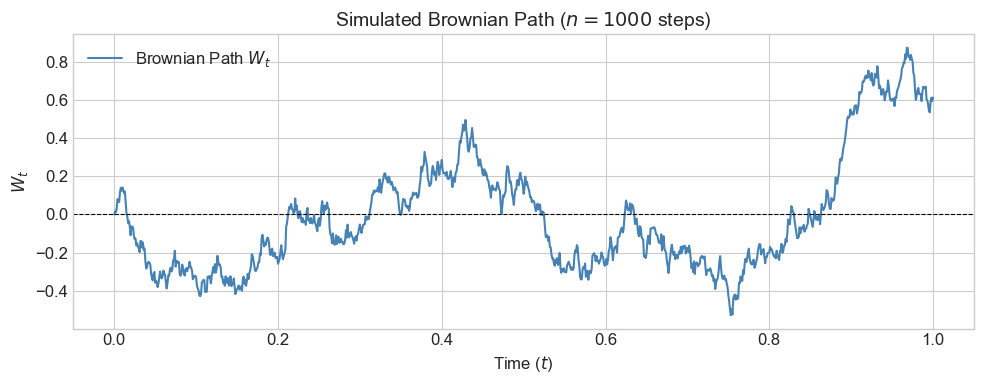

In [4]:
# (c) Compute midpoint sum
sum_mid = np.sum((W[:-1] + W[1:]) / 2.0 * dW)
analytical_mid = 0.5 * W_1**2

print(f"--- (c) Midpoint (Stratonovich) ---")
print(f"Numerical Sum : {sum_mid:.4f}")
print(f"Analytical    : {analytical_mid:.4f}")
print(f"Difference    : {abs(sum_mid - analytical_mid):.4f}\n")

# Visual Metric: The Brownian Path
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_grid, W, color='steelblue', linewidth=1.5, label='Brownian Path $W_t$')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Simulated Brownian Path ($n=1000$ steps)", fontsize=14)
ax.set_xlabel("Time ($t$)", fontsize=12)
ax.set_ylabel("$W_t$", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
### Part (d): Monte Carlo Convergence of Expectations

While individual pathwise sums depend on the specific realization of $W_1$, taking the expectation across many paths reveals the probabilistic properties of these integrals. Since $W_1 \sim N(0,1)$, we know $E[W_1^2] = 1$. Consequently, the theoretical expectations are:

*   **Itô (Left):** $E[\frac{1}{2}(W_1^2 - 1)] = \frac{1}{2}(1 - 1) = 0$ (Martingale property).
*   **Right:** $E[\frac{1}{2}(W_1^2 + 1)] = \frac{1}{2}(1 + 1) = 1$.
*   **Stratonovich (Mid):** $E[\frac{1}{2}W_1^2] = 0.5$.

We simulate 1,000 independent Brownian paths and calculate the average of each sum. We repeat this process as the partition size $n$ doubles from $100$ to $102,400$ to demonstrate asymptotic convergence.

--- (d) Monte Carlo Convergence ---
Simulation completed in 6.11 seconds.

Empirical Expectations at n = 102400:
Left (Expected 0.0) : 0.0404
Right (Expected 1.0): 1.0407
Mid (Expected 0.5)  : 0.5405


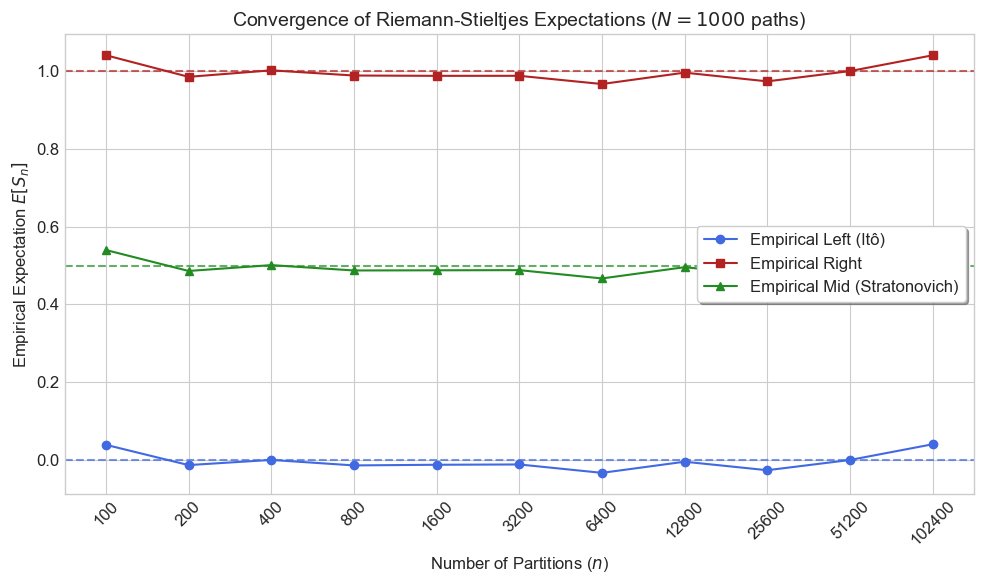

In [5]:
import time

print("--- (d) Monte Carlo Convergence ---")
start_time = time.time()

num_paths = 1000
# Sequence doubling from 100 up to 102,400
n_values = [100 * (2**i) for i in range(11)] 

# Storage for empirical expectations
exp_left = []
exp_right = []
exp_mid = []

for n_steps in n_values:
    dt_step = 1.0 / n_steps
    
    # Generate 1000 paths simultaneously (Vectorized)
    dW_mc = np.random.normal(0, np.sqrt(dt_step), (num_paths, n_steps))
    W_mc = np.concatenate((np.zeros((num_paths, 1)), np.cumsum(dW_mc, axis=1)), axis=1)
    
    # Compute sums across all paths simultaneously
    sums_left = np.sum(W_mc[:, :-1] * dW_mc, axis=1)
    sums_right = np.sum(W_mc[:, 1:] * dW_mc, axis=1)
    sums_mid = np.sum((W_mc[:, :-1] + W_mc[:, 1:]) / 2.0 * dW_mc, axis=1)
    
    # Append the mean (empirical expectation)
    exp_left.append(np.mean(sums_left))
    exp_right.append(np.mean(sums_right))
    exp_mid.append(np.mean(sums_mid))

print(f"Simulation completed in {time.time() - start_time:.2f} seconds.\n")

# Self-Check at n = 102,400
print(f"Empirical Expectations at n = {n_values[-1]}:")
print(f"Left (Expected 0.0) : {exp_left[-1]:.4f}")
print(f"Right (Expected 1.0): {exp_right[-1]:.4f}")
print(f"Mid (Expected 0.5)  : {exp_mid[-1]:.4f}")

# Visual Metric: Convergence Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_values, exp_left, marker='o', color='royalblue', label='Empirical Left (Itô)')
ax.plot(n_values, exp_right, marker='s', color='firebrick', label='Empirical Right')
ax.plot(n_values, exp_mid, marker='^', color='forestgreen', label='Empirical Mid (Stratonovich)')

# Theoretical reference lines
ax.axhline(0.0, color='royalblue', linestyle='--', alpha=0.7)
ax.axhline(1.0, color='firebrick', linestyle='--', alpha=0.7)
ax.axhline(0.5, color='forestgreen', linestyle='--', alpha=0.7)

ax.set_xscale('log') # Log scale handles the doubling sequence beautifully
ax.set_xticks(n_values)
ax.set_xticklabels(n_values, rotation=45)

ax.set_title("Convergence of Riemann-Stieltjes Expectations ($N=1000$ paths)", fontsize=14)
ax.set_xlabel("Number of Partitions ($n$)", fontsize=12)
ax.set_ylabel("Empirical Expectation $E[S_n]$", fontsize=12)
ax.legend(loc='center right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()